In [47]:
from utils import CVRP
import re
import matplotlib.pyplot as plt
import numpy as np
from testing import load_results

In [90]:
plt.style.use("ggplot")

In [49]:
def _get_greedy_result_dict():
    problem_names = ["datasets/A/A-n32-k5", "datasets/A/A-n46-k7", "datasets/A/A-n60-k9", "datasets/B/B-n41-k6", "datasets/B/B-n43-k6", "datasets/B/B-n45-k5", "datasets/X/X-n110-k13", "datasets/X/X-n172-k51"]
    return {problem_name.split("/")[2]: CVRP(problem_name).heuristic_cost / CVRP(problem_name).minimal_cost - 1 for problem_name in problem_names}

In [106]:
def create_specific_result_dict(dataset_names, method_names, statistic, result_dict, greedy_result_dict = None, mini = True):
    out_dict = {}
    keys = result_dict.keys()
    for dataset_name in dataset_names:
        dataset_dict = {}
        for method_name in method_names:
            stats = []
            for key in keys:
                if re.search(rf"{dataset_name}.*{method_name}.*", key):
                    stats.append(result_dict[key][statistic])
            dataset_dict[method_name] = min(stats) if mini else max(stats)
        if greedy_result_dict and statistic in ["best_gap", "mean_gap"]:
            dataset_dict["greedy"] = greedy_result_dict[dataset_name.split("/")[2]]
        out_dict[dataset_name.split("/")[2]] = dataset_dict
    return out_dict

In [84]:
def plot_dict_barplots(data, statistic, path = None):
    datasets = list(data.keys())

    # Collect all unique methods
    methods = sorted({m for d in data.values() for m in d.keys()})

    n_datasets = len(datasets)

    fig, axes = plt.subplots(1, n_datasets, figsize=(4 * n_datasets, 4), sharey=True)

    if n_datasets == 1:
        axes = [axes]

    # Consistent colors per method
    cmap = plt.get_cmap("tab10")
    colors = {method: cmap(i) for i, method in enumerate(methods)}

    for ax, dataset in zip(axes, datasets):
        values = data[dataset]

        y = []
        invalid_mask = []

        for m in methods:
            val = values.get(m, np.nan)
            is_valid = np.isfinite(val)
            y.append(val if is_valid else np.nan)
            invalid_mask.append(not is_valid)

        x = np.arange(len(methods))

        ax.bar(x, y, color=[colors[m] for m in methods])
        ax.set_xticks(x)
        ax.set_xticklabels(methods, rotation=45)
        ax.set_title(dataset)

        # Color invalid method labels red
        for tick_label, is_invalid in zip(ax.get_xticklabels(), invalid_mask):
            if is_invalid:
                tick_label.set_color("red")

    axes[0].set_ylabel(statistic)

    # Shared legend
    handles = [plt.Rectangle((0, 0), 1, 1, color=colors[m]) for m in methods]
    fig.legend(handles, methods, loc="upper center", ncol=len(methods))

    plt.tight_layout(rect=[0, 0, 1, 0.9])

    if path is not None:
        plt.savefig(path, bbox_inches="tight", dpi=300)

    plt.show()

# General setup

In [127]:
result_dict = load_results('compact_results.json')
method_names = ["AS", "ACS", "MINMAX"]
greedy_result_dict = _get_greedy_result_dict()

# Hypo 1

In [128]:
statistic = "best_gap"
dataset_names = ["datasets/A/A-n32-k5", "datasets/A/A-n46-k7", "datasets/A/A-n60-k9"]
data = create_specific_result_dict(dataset_names, method_names, statistic, result_dict, greedy_result_dict)

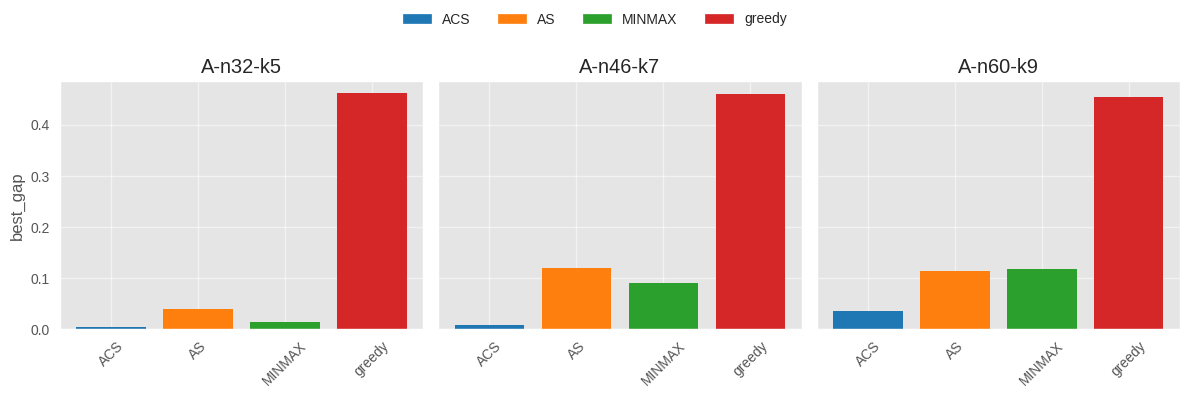

In [129]:
path = "plot_1_a.png"
plot_dict_barplots(data, statistic, path)

In [130]:
dataset_names = ["datasets/B/B-n41-k6", "datasets/B/B-n43-k6", "datasets/B/B-n45-k5"]
data = create_specific_result_dict(dataset_names, method_names, statistic, result_dict, greedy_result_dict)

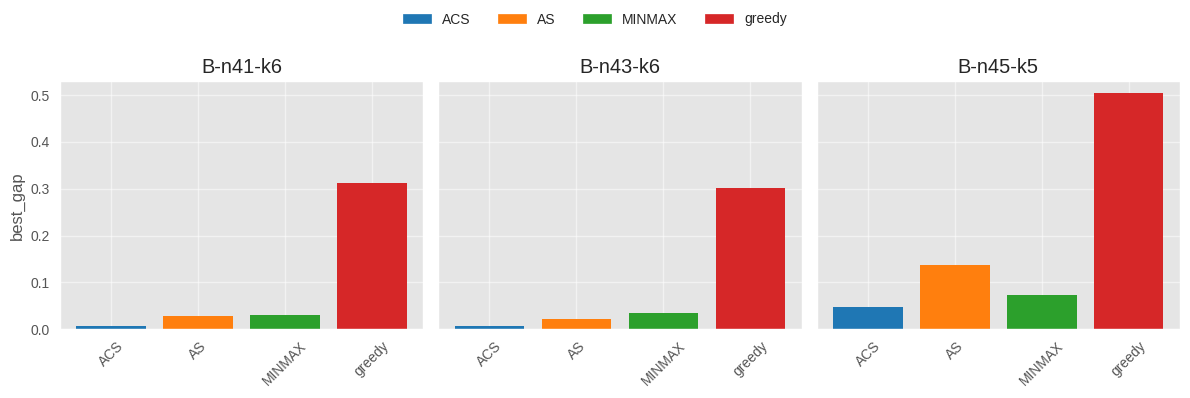

In [131]:
path = "plot_1_b.png"
plot_dict_barplots(data, statistic, path)

In [132]:
dataset_names = ["datasets/X/X-n110-k13"]
data = create_specific_result_dict(dataset_names, method_names, statistic, result_dict, greedy_result_dict)

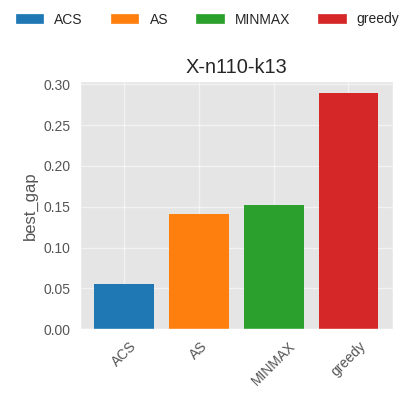

In [133]:
path = "plot_1_x.png"
plot_dict_barplots(data, statistic, path)

# Hypo 2

In [123]:
statistic = "best_gap"
dataset_names = ["datasets/A/A-n32-k5", "datasets/A/A-n46-k7", "datasets/A/A-n60-k9"]
data = create_specific_result_dict(dataset_names, method_names, statistic, result_dict)

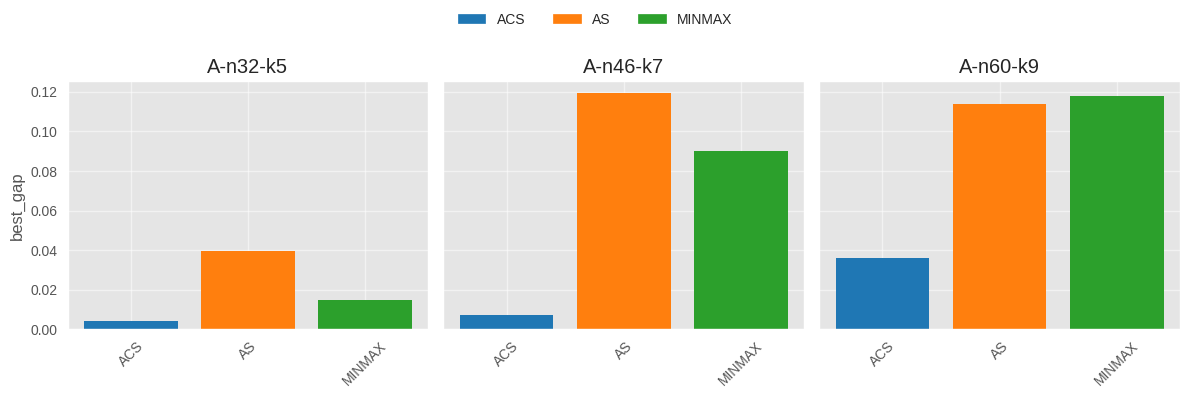

In [124]:
path = "plot_2_a.png"
plot_dict_barplots(data, statistic, path)

In [125]:
dataset_names = ["datasets/B/B-n41-k6", "datasets/B/B-n43-k6", "datasets/B/B-n45-k5"]
data = create_specific_result_dict(dataset_names, method_names, statistic, result_dict)

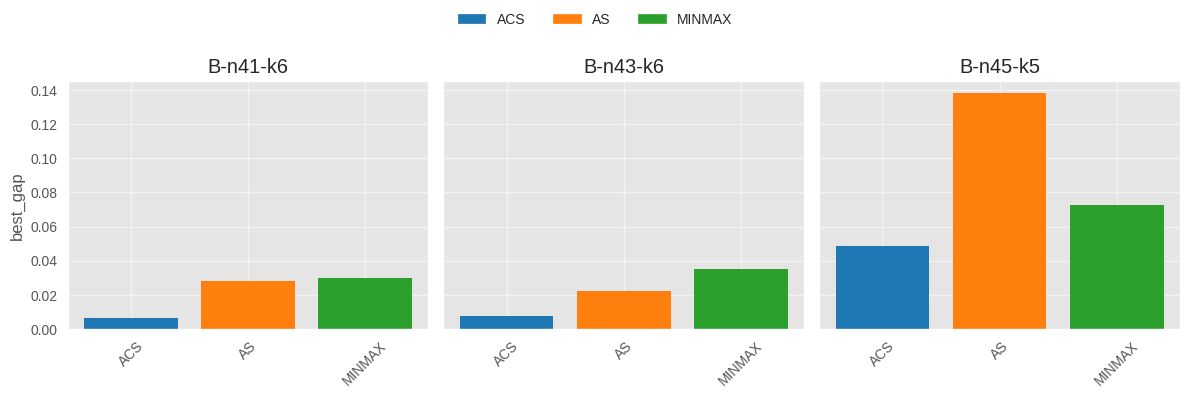

In [126]:
path = "plot_2_b.png"
plot_dict_barplots(data, statistic, path)

# Hypo 3

## mean_conv_iter

In [134]:
statistic = "mean_conv_iterations"
dataset_names = ["datasets/A/A-n32-k5", "datasets/A/A-n46-k7", "datasets/A/A-n60-k9"]
data = create_specific_result_dict(dataset_names, method_names, statistic, result_dict, greedy_result_dict)

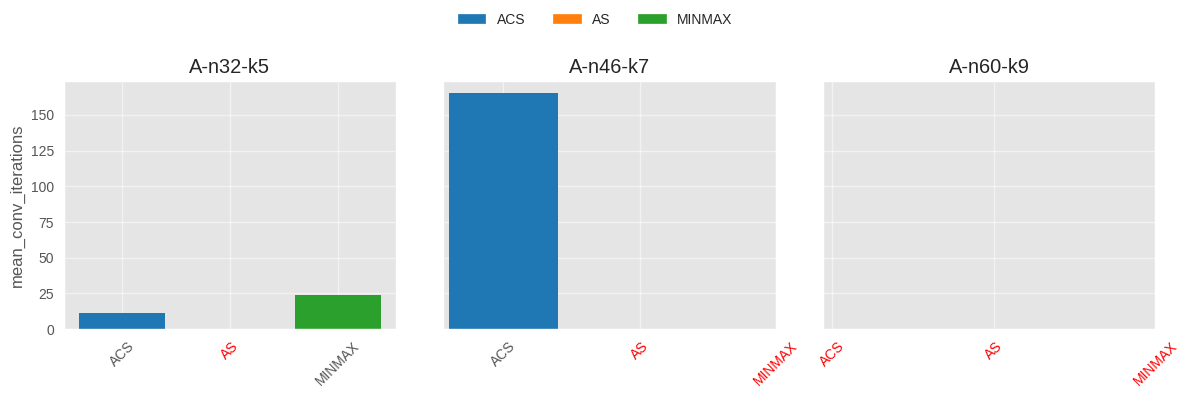

In [135]:
path = "plot_3_a_m.png"
plot_dict_barplots(data, statistic, path)

In [138]:
dataset_names = ["datasets/B/B-n41-k6", "datasets/B/B-n43-k6", "datasets/B/B-n45-k5"]
data = create_specific_result_dict(dataset_names, method_names, statistic, result_dict, greedy_result_dict)

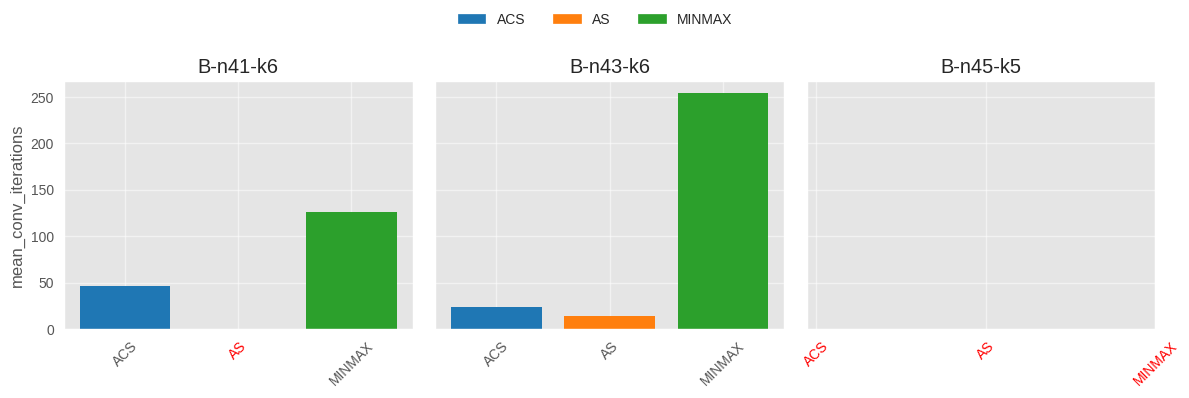

In [139]:
path = "plot_3_b_m.png"
plot_dict_barplots(data, statistic, path)

In [141]:
dataset_names = ["datasets/X/X-n110-k13"]
data = create_specific_result_dict(dataset_names, method_names, statistic, result_dict, greedy_result_dict)

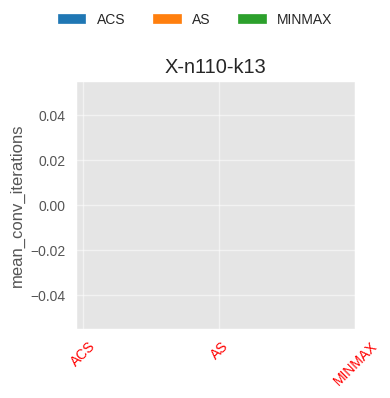

In [142]:
path = "plot_3_x_m.png"
plot_dict_barplots(data, statistic, path)

## mean_conv_iter var